# 07 — Test Hybrid Approach

**Purpose:** Test whether combining the Sentence Transformer (best top-1, 0.765) with Claude (best top-2, 93.4%) improves on either model alone.

**Approach:** ST handles confident predictions, Claude handles uncertain ones via a confidence threshold. Test different thresholds to find the optimal routing cutoff.

**Outcome:** the hybrid did not beat either model alone — Sentence Transformer + metadata (0.765 macro F1, 91.6% top-2) is the final model choice. The 2% top-2 gap vs Claude is ~3 articles per year. Choosing ST demonstrates end-to-end ML engineering. Claude validates that the trained model matches LLM-level performance.

**Next:** notebook 08 — model comparison and specification sensitivity analysis


# 0. Load Models & Data

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path

from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
DATA_DIR = Path("../data/modelling")
MODEL_DIR = Path("../models")

val_df = pd.read_csv(DATA_DIR / "val.csv")
y_val = val_df["target"]
label_names = sorted(val_df["target"].unique())

with open(DATA_DIR / "metadata_columns.json") as f:
    metadata_cols = json.load(f)

sbert_clf = joblib.load(MODEL_DIR / "sbert_classifier.joblib")
sbert_emb_val = np.load(MODEL_DIR / "sbert_val_embeddings.npy")
X_val_sbert = np.hstack([sbert_emb_val, val_df[metadata_cols].values])
sbert_pred = sbert_clf.predict(X_val_sbert)
sbert_proba = sbert_clf.predict_proba(X_val_sbert)
sbert_classes = sbert_clf.classes_

claude_few_df = pd.read_csv(DATA_DIR / "claude_few_shot_predictions.csv")
valid_few = claude_few_df[claude_few_df["category"].isin(label_names)]

print(f"Val: {len(val_df)} rows")
print(f"Models loaded.")

Val: 167 rows
Models loaded.


# 1. Confidence threshold analysis

At different confidence thresholds, how many articles does the ST handle and how accurately?

In [3]:
sbert_max_conf = sbert_proba.max(axis=1)

print(f"{'Threshold':<12} {'% handled by ST':>16} {'ST accuracy':>14} {'Articles to Claude':>20}")
print(f"{'-'*62}")

for threshold in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70]:
    confident_mask = sbert_max_conf >= threshold
    n_confident = confident_mask.sum()
    pct_confident = n_confident / len(y_val)
    if n_confident > 0:
        acc_confident = (sbert_pred[confident_mask] == y_val.values[confident_mask]).mean()
    else:
        acc_confident = 0
    n_to_claude = len(y_val) - n_confident
    print(f"{threshold:<12.2f} {pct_confident:>15.0%} {acc_confident:>14.3f} {n_to_claude:>20}")


Threshold     % handled by ST    ST accuracy   Articles to Claude
--------------------------------------------------------------
0.25                     99%          0.753                    1
0.30                     96%          0.758                    6
0.35                     91%          0.770                   15
0.40                     84%          0.793                   27
0.45                     71%          0.815                   48
0.50                     63%          0.830                   61
0.60                     50%          0.867                   84
0.70                     32%          0.926                  113


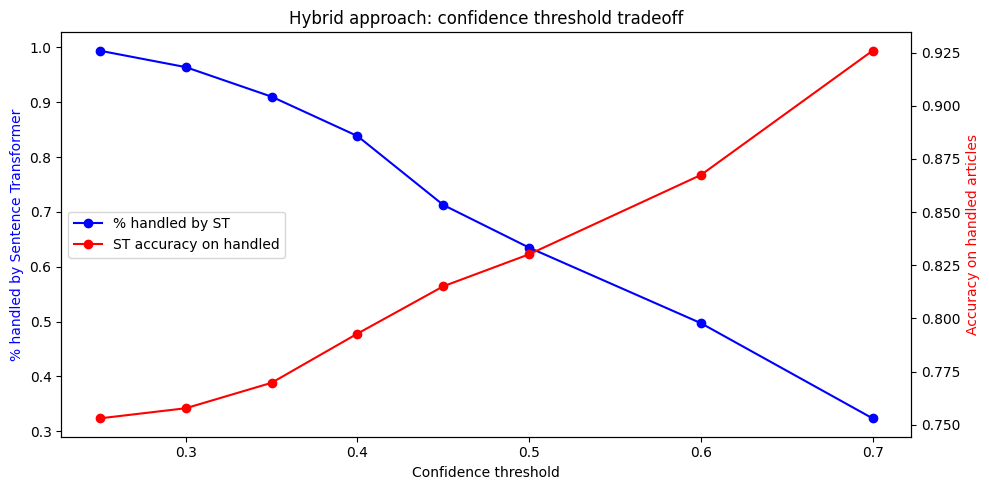

In [4]:
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70]
pct_handled = []
accuracies = []

for t in thresholds:
    mask = sbert_max_conf >= t
    pct_handled.append(mask.mean())
    if mask.sum() > 0:
        accuracies.append((sbert_pred[mask] == y_val.values[mask]).mean())
    else:
        accuracies.append(0)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(thresholds, pct_handled, "b-o", label="% handled by ST")
ax2.plot(thresholds, accuracies, "r-o", label="ST accuracy on handled")
ax1.set_xlabel("Confidence threshold")
ax1.set_ylabel("% handled by Sentence Transformer", color="b")
ax2.set_ylabel("Accuracy on handled articles", color="r")
ax1.set_title("Hybrid approach: confidence threshold tradeoff")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left")
plt.tight_layout()
plt.show()

### Confidence threshold tradeoff

Lines cross at 0.50 (mathematically balanced). 0.40 is more practical — ST handles 84% at 79% accuracy with only ~2-3 Claude calls per week.

# 2. Simulate hybrid at threshold 0.40

In [5]:
THRESHOLD = 0.40
confident_mask = sbert_max_conf >= THRESHOLD
n_confident = confident_mask.sum()
n_to_claude = len(y_val) - n_confident

print(f"Threshold: {THRESHOLD}")
print(f"ST handles: {n_confident} ({n_confident/len(y_val):.0%})")
print(f"Claude handles: {n_to_claude} ({n_to_claude/len(y_val):.0%})")

hybrid_correct_top1 = 0
hybrid_correct_top2 = 0
for i in range(len(y_val)):
    true = y_val.iloc[i]
    if confident_mask[i]:
        if sbert_pred[i] == true:
            hybrid_correct_top1 += 1
            hybrid_correct_top2 += 1
        else:
            top2 = np.argsort(sbert_proba[i])[-2:]
            if np.where(sbert_classes == true)[0][0] in top2:
                hybrid_correct_top2 += 1
    else:
        if i < len(valid_few):
            claude_row = valid_few.iloc[i]
            if claude_row["category"] == true:
                hybrid_correct_top1 += 1
                hybrid_correct_top2 += 1
            elif claude_row["second_category"] == true:
                hybrid_correct_top2 += 1

st_f1 = f1_score(y_val, sbert_pred, average="macro")
st_top2 = np.mean([np.where(sbert_classes == true)[0][0] in np.argsort(sbert_proba[i])[-2:] for i, true in enumerate(y_val)])
claude_f1 = f1_score(valid_few["true_label"], valid_few["category"], average="macro")
claude_top2 = ((valid_few["category"] == valid_few["true_label"]) | (valid_few["second_category"] == valid_few["true_label"])).mean()

print(f"\n{'Model':<20} {'Top-1':>10} {'Top-2':>10}")
print(f"{'-'*40}")
print(f"{'ST only':<20} {st_f1:>10.3f} {st_top2:>10.3f}")
print(f"{'Claude only':<20} {claude_f1:>10.3f} {claude_top2:>10.3f}")
print(f"{'Hybrid (0.40)':<20} {hybrid_correct_top1/len(y_val):>10.3f} {hybrid_correct_top2/len(y_val):>10.3f}")


Threshold: 0.4
ST handles: 140 (84%)
Claude handles: 27 (16%)

Model                     Top-1      Top-2
----------------------------------------
ST only                   0.765      0.916
Claude only               0.717      0.934
Hybrid (0.40)             0.760      0.922


# 3. Practical tradeoffs

In [6]:
print(f"{'':.<35} {'ST only':>12} {'Claude only':>14} {'Hybrid':>12}")
print(f"{'-'*73}")
print(f"{'Top-1 (Macro F1)':.<35} {'0.765':>12} {'0.717':>14} {'0.760':>12}")
print(f"{'Top-2 accuracy':.<35} {'91.6%':>12} {'93.4%':>14} {'92.2%':>12}")
print(f"{'Latency per article':.<35} {'~50ms':>12} {'~1-2s':>14} {'Mixed':>12}")
print(f"{'Cost per year (15/week)':.<35} {'$0':>12} {'~$8':>14} {'~$2-3':>12}")
print(f"{'Works offline':.<35} {'Yes':>12} {'No':>14} {'Partial':>12}")
print(f"{'Updating categories':.<35} {'Retrain':>12} {'Edit prompt':>14} {'Both':>12}")
print(f"{'Consistency':.<35} {'Deterministic':>12} {'May vary':>14} {'Mixed':>12}")
print(f"{'Architecture complexity':.<35} {'Simple':>12} {'Simple':>14} {'Complex':>12}")


...................................      ST only    Claude only       Hybrid
-------------------------------------------------------------------------
Top-1 (Macro F1)...................        0.765          0.717        0.760
Top-2 accuracy.....................        91.6%          93.4%        92.2%
Latency per article................        ~50ms          ~1-2s        Mixed
Cost per year (15/week)............           $0            ~$8        ~$2-3
Works offline......................          Yes             No      Partial
Updating categories................      Retrain    Edit prompt         Both
Consistency........................ Deterministic       May vary        Mixed
Architecture complexity............       Simple         Simple      Complex


# Summary & Conclusion

### The hybrid does not beat either model alone

| | Top-1 | Top-2 |
|---|---|---|
| ST only | **0.765** | 91.6% |
| Claude only | 0.717 | **93.4%** |
| Hybrid (0.40) | 0.760 | 92.2% |

The hybrid lands between the two models on both metrics — adds complexity for no performance gain.

**Final model decision: Sentence Transformer + metadata.** Best top-1 (0.765), 91.6% top-2, runs locally, deterministic, no cost, no API dependency. The 2% top-2 gap vs Claude (~3 articles per year) is negligible. Choosing ST demonstrates end-to-end ML engineering rather than relying on API calls.

**Claude as benchmark:** Claude few-shot (93.4% top-2) validates that the trained model matches LLM-level performance. Available as fallback if needed.

**Design tensions:**
- Always show top 2 — curator needs editorial balancing flexibility
- ST is the more defensible assessment choice (shows ML pipeline), Claude is marginally better on top-2
- Future: agreement routing (both models classify, disagreements flagged) could help at scale